# Influence of Viscous Damping on Platform Motions

Analysis of how different viscous damping configurations affect motion responses (heave, pitch, roll) across sea states and wave directions.

**Damping cases:**
- `low` — reference (minimal viscous damping)
- `linhigh` — high linear damping
- `quadhigh` — high quadratic damping
- `Average` (stored as `DOFbest` in CSV) — best per-DOF combination

**Filters applied:**
- Pitch: Direction = 90° excluded (beam seas, pitch barely excited)
- Roll: Direction = 0° and 180° excluded (head/following seas, roll barely excited)

**Metrics:**
- `std` — standard deviation of the motion signal
- `max` — already corrected (max minus mean)
- Peak factor — `max / std` (indicates how peaky the response is vs. its RMS-like spread)
- Reduction — `(value_low − value_case) / value_low × 100%` (damping effectiveness relative to reference)

## Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- Font sizes (used everywhere) ----
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14

plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': TICK_SIZE,
    'figure.titlesize': TITLE_SIZE,
})

# ---- Layout switch ----
# 'big_canvas'  -> one large figure per tier with motions side-by-side
# 'per_motion'  -> one figure per motion
LAYOUT_MODE = 'big_canvas'

# ---- Data path ----
CSV_PATH = 'results/resultscombined_all.csv'

# ---- Damping config: display labels, order, colors ----
# Keys are the raw values in the CSV; display names are what appear in plots.
DAMP_LABELS = {
    'low':      'low',
    'linhigh':  'linhigh',
    'quadhigh': 'quadhigh',
    'DOFbest':  'Average',
}
DAMP_ORDER = ['low', 'linhigh', 'quadhigh', 'DOFbest']  # internal keys, in plotting order
DAMP_COLORS = {
    'low':      '#1f77b4',  # blue, reference
    'linhigh':  '#ff7f0e',  # orange
    'quadhigh': '#2ca02c',  # green
    'DOFbest':  '#d62728',  # red (Average)
}
DAMP_LINESTYLES = {
    'low':      '--',  # dashed: reference
    'linhigh':  '-',
    'quadhigh': '-',
    'DOFbest':  '-',
}
REFERENCE_CASE = 'low'

# ---- Motion config: which directions to exclude per motion ----
MOTIONS = ['heave', 'pitch', 'roll']
MOTION_LABELS = {'heave': 'Heave', 'pitch': 'Pitch', 'roll': 'Roll'}
MOTION_UNITS = {'heave': 'm', 'pitch': 'deg', 'roll': 'deg'}
EXCLUDE_DIRS = {
    'heave': set(),
    'pitch': {90},
    'roll':  {0, 180},
}

# ---- Load data ----
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('Hs values:', sorted(df['Hs'].unique()))
print('Tp values:', sorted(df['Tp'].unique()))
print('Directions:', sorted(df['Direction'].unique()))
print('Damp configs:', df['damp_config'].unique().tolist())
df.head()

Shape: (440, 10)
Hs values: [np.float64(1.0), np.float64(2.0), np.float64(4.0)]
Tp values: [np.float64(3.58), np.float64(4.08), np.float64(4.36), np.float64(4.58), np.float64(6.540000000000001), np.float64(6.59), np.float64(7.09), np.float64(7.59), np.float64(8.72), np.float64(10.9), np.float64(13.080000000000002)]
Directions: [np.int64(0), np.int64(45), np.int64(90), np.int64(135), np.int64(180)]
Damp configs: ['low', 'linhigh', 'quadhigh', 'DOFbest']


,Hs,Tp,Direction,damp_config,heave_std,pitch_std,roll_std,heave_max,pitch_max,roll_max
0,2.0,4.36,0,low,0.128777,1.726431,0.000117,0.430916,5.946870,0.001054
1,2.0,4.36,45,low,0.139251,0.779213,1.203765,0.453103,2.769774,4.693894
2,2.0,4.36,90,low,0.123696,0.761861,0.726094,0.387618,2.850720,2.807936
3,2.0,4.36,135,low,0.135579,0.589055,0.402547,0.483522,2.347855,1.695440
4,2.0,4.36,180,low,0.158334,1.895306,0.000134,0.527365,7.149684,0.001112


## Helpers

In [2]:
def filter_motion(df_in, motion):
    """Drop directions where this motion is barely excited."""
    excl = EXCLUDE_DIRS[motion]
    if not excl:
        return df_in.copy()
    return df_in[~df_in['Direction'].isin(excl)].copy()


def directions_for(motion):
    """Sorted list of directions actually used for a motion."""
    return sorted(d for d in df['Direction'].unique() if d not in EXCLUDE_DIRS[motion])


def hs_values():
    return sorted(df['Hs'].unique())


def damp_handles():
    """Build legend handles in the configured order, using display labels."""
    return [
        Line2D([0], [0],
               color=DAMP_COLORS[d],
               linestyle=DAMP_LINESTYLES[d],
               marker='o', markersize=5,
               label=DAMP_LABELS[d])
        for d in DAMP_ORDER
    ]


def plot_lines_on_ax(ax, sub, ycol, *, show_low=True):
    """Plot one line per damp case on a single axis. sub is filtered to one (Hs, Direction)."""
    for d in DAMP_ORDER:
        if d == REFERENCE_CASE and not show_low:
            continue
        s = sub[sub['damp_config'] == d].sort_values('Tp')
        if s.empty:
            continue
        ax.plot(s['Tp'], s[ycol],
                color=DAMP_COLORS[d],
                linestyle=DAMP_LINESTYLES[d],
                marker='o', markersize=5,
                linewidth=2)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)


def compute_reduction(df_in, value_col):
    """Add a 'reduction_pct' column: (value_low - value_case) / value_low * 100.
    Reduction is computed within each (Hs, Tp, Direction) group."""
    ref = df_in[df_in['damp_config'] == REFERENCE_CASE][
        ['Hs', 'Tp', 'Direction', value_col]
    ].rename(columns={value_col: f'{value_col}_ref'})
    out = df_in.merge(ref, on=['Hs', 'Tp', 'Direction'], how='left')
    out['reduction_pct'] = (out[f'{value_col}_ref'] - out[value_col]) / out[f'{value_col}_ref'] * 100
    return out


# Sanity check on filters
for m in MOTIONS:
    print(f'{m}: directions = {directions_for(m)}')

heave: directions = [np.int64(0), np.int64(45), np.int64(90), np.int64(135), np.int64(180)]
pitch: directions = [np.int64(0), np.int64(45), np.int64(135), np.int64(180)]
roll: directions = [np.int64(45), np.int64(90), np.int64(135)]


## Grid plotter (used by Tiers 1, 2, 3)

Each tier produces, per motion, a grid of (Hs rows) × (Direction columns) of Tp-vs-y line plots. In `big_canvas` mode all three motions are placed side-by-side in one large figure; in `per_motion` mode each motion is its own figure.

In [3]:
def make_grid_per_motion(motion, ycol, ylabel, *, show_low, transform=None):
    """Build the (Hs x Direction) subplot grid for a single motion.
    Returns (fig, axes_2d)."""
    d_sub = filter_motion(df, motion)
    if transform is not None:
        d_sub = transform(d_sub)

    hss = hs_values()
    dirs = directions_for(motion)
    n_rows, n_cols = len(hss), len(dirs)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.6 * n_cols, 3.0 * n_rows),
        sharex=True, sharey='row',
        squeeze=False,
    )

    for i, hs in enumerate(hss):
        for j, direc in enumerate(dirs):
            ax = axes[i, j]
            sub = d_sub[(d_sub['Hs'] == hs) & (d_sub['Direction'] == direc)]
            plot_lines_on_ax(ax, sub, ycol, show_low=show_low)
            if i == 0:
                ax.set_title(f'Dir = {direc}°', fontsize=LABEL_SIZE)
            if j == 0:
                ax.set_ylabel(f'Hs = {hs} m\n{ylabel}', fontsize=LABEL_SIZE)
            if i == n_rows - 1:
                ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

    fig.suptitle(f'{MOTION_LABELS[motion]} — {ylabel}', fontsize=TITLE_SIZE, y=1.00)
    fig.legend(
        handles=damp_handles(),
        loc='upper center', bbox_to_anchor=(0.5, -0.02),
        ncol=len(DAMP_ORDER), frameon=False, fontsize=TICK_SIZE,
    )
    fig.tight_layout()
    return fig, axes


def make_grid_big_canvas(ycol_template, ylabel_template, *, show_low, transform=None,
                          super_title=None):
    """Build one big figure containing the (Hs x Direction) grid for all three motions side-by-side.
    Column counts differ per motion (due to direction filters), so we use GridSpec.
    ycol_template / ylabel_template are functions of motion name."""
    hss = hs_values()
    dirs_per_motion = {m: directions_for(m) for m in MOTIONS}
    cols_per_motion = {m: len(dirs_per_motion[m]) for m in MOTIONS}
    total_cols = sum(cols_per_motion.values())

    fig = plt.figure(figsize=(3.6 * total_cols, 3.0 * len(hss) + 1.0))
    gs = fig.add_gridspec(
        nrows=len(hss), ncols=total_cols,
        wspace=0.25, hspace=0.30,
    )

    col_offset = 0
    for m in MOTIONS:
        d_sub = filter_motion(df, m)
        ycol = ycol_template(m)
        ylabel = ylabel_template(m)
        if transform is not None:
            d_sub = transform(d_sub, m, ycol)

        dirs = dirs_per_motion[m]
        n_cols_m = cols_per_motion[m]

        # collect row-wise axes for sharey within this motion block
        motion_axes = []
        for i, hs in enumerate(hss):
            row_axes = []
            for j, direc in enumerate(dirs):
                share_y = row_axes[0] if j > 0 else None
                ax = fig.add_subplot(gs[i, col_offset + j], sharey=share_y)
                sub = d_sub[(d_sub['Hs'] == hs) & (d_sub['Direction'] == direc)]
                plot_lines_on_ax(ax, sub, ycol, show_low=show_low)

                if i == 0:
                    if j == n_cols_m // 2:
                        ax.set_title(f'{MOTION_LABELS[m]}\nDir = {direc}°', fontsize=LABEL_SIZE)
                    else:
                        ax.set_title(f'Dir = {direc}°', fontsize=LABEL_SIZE)
                if j == 0 and col_offset == 0:
                    ax.set_ylabel(f'Hs = {hs} m\n{ylabel}', fontsize=LABEL_SIZE)
                elif j == 0:
                    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
                if j > 0:
                    plt.setp(ax.get_yticklabels(), visible=False)
                if i == len(hss) - 1:
                    ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
                row_axes.append(ax)
            motion_axes.append(row_axes)

        col_offset += n_cols_m

    if super_title:
        fig.suptitle(super_title, fontsize=TITLE_SIZE, y=1.00)
    fig.legend(
        handles=damp_handles(),
        loc='upper center', bbox_to_anchor=(0.5, -0.01),
        ncol=len(DAMP_ORDER), frameon=False, fontsize=TICK_SIZE,
    )
    return fig


def render_tier(ycol_template, ylabel_template, *, show_low,
                 transform_big=None, transform_per=None, super_title=None):
    """Dispatch on LAYOUT_MODE."""
    if LAYOUT_MODE == 'big_canvas':
        fig = make_grid_big_canvas(
            ycol_template, ylabel_template,
            show_low=show_low, transform=transform_big,
            super_title=super_title,
        )
        plt.show()
    elif LAYOUT_MODE == 'per_motion':
        for m in MOTIONS:
            ycol = ycol_template(m)
            ylabel = ylabel_template(m)
            fig, _ = make_grid_per_motion(
                m, ycol, ylabel,
                show_low=show_low,
                transform=(lambda d, _m=m, _y=ycol: transform_per(d, _m, _y)) if transform_per else None,
            )
            plt.show()
    else:
        raise ValueError(f'Unknown LAYOUT_MODE: {LAYOUT_MODE}')

## Tier 1 — Absolute response

Tp vs **std** and Tp vs **max** (max already mean-corrected), one line per damping case. Read these for: where is the absolute response largest, and how do the damping cases rank in absolute terms.

### Tier 1a — Standard deviation

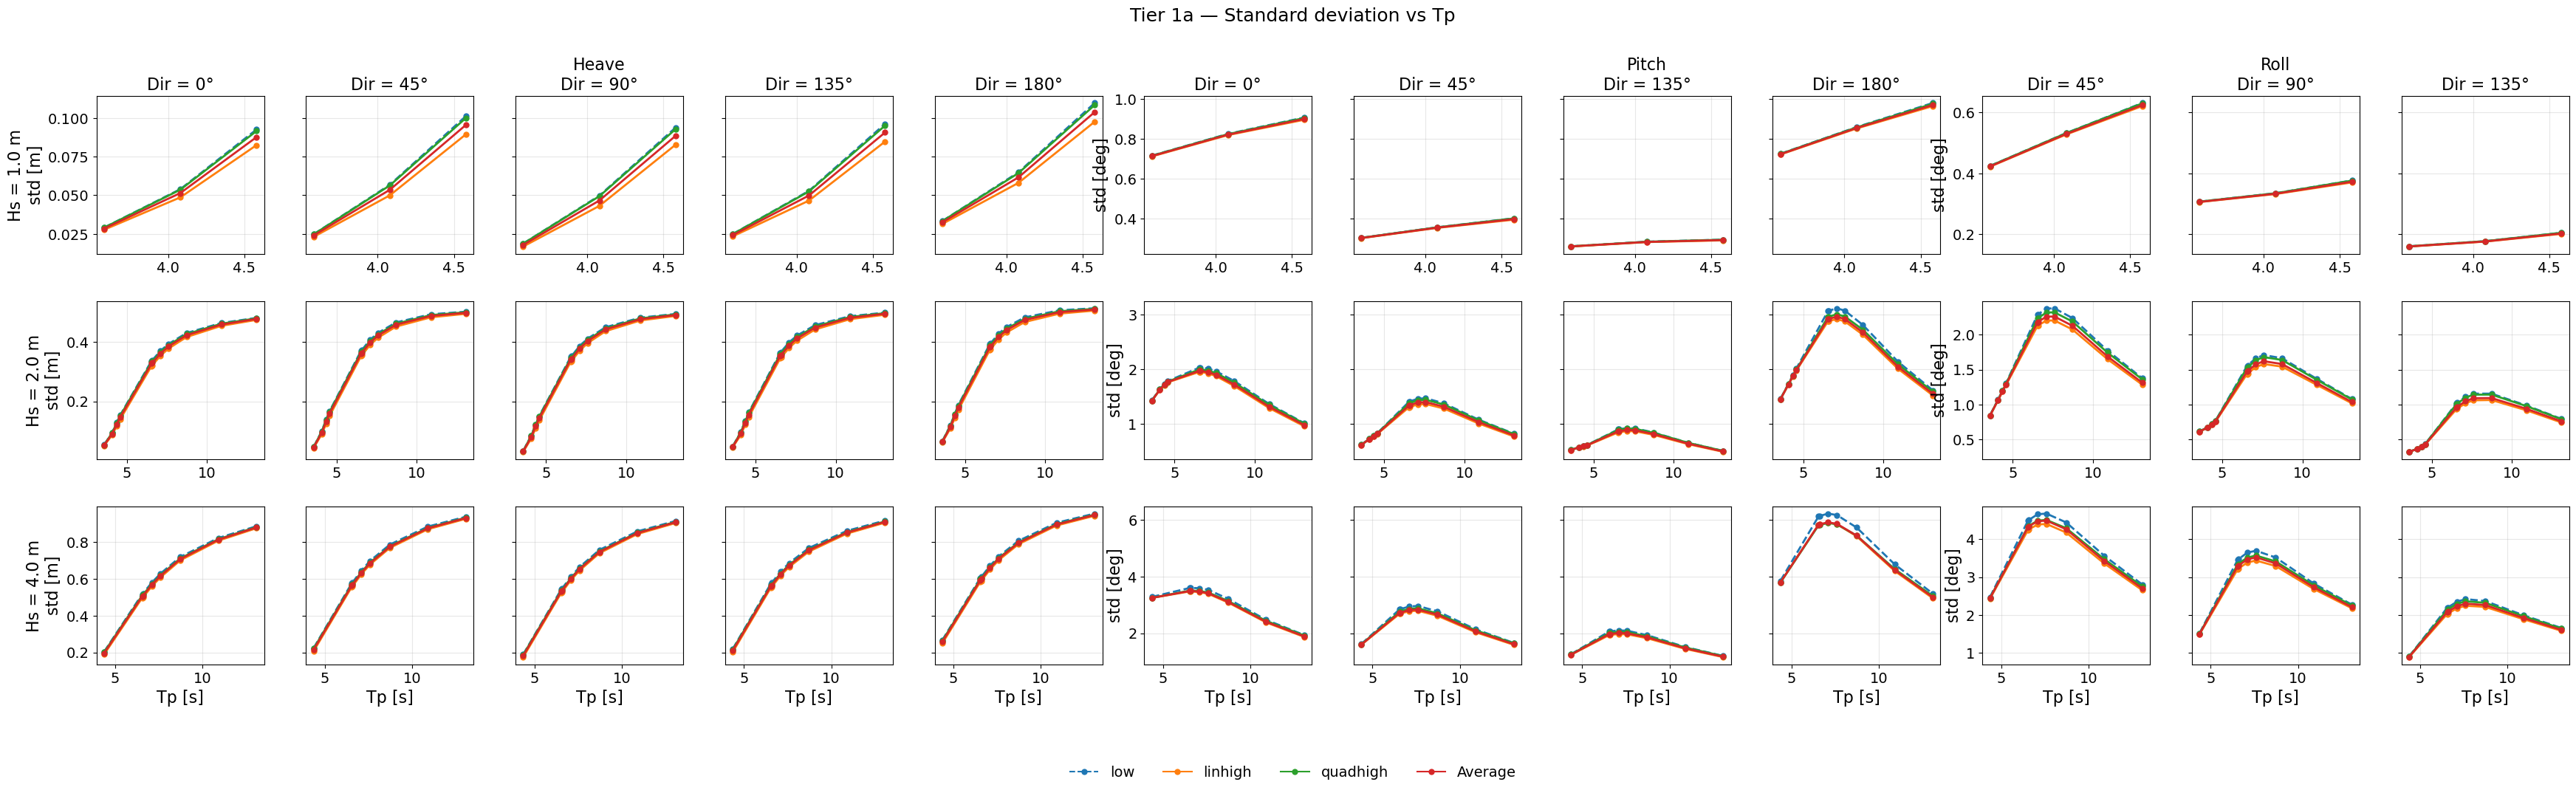

In [4]:
render_tier(
    ycol_template=lambda m: f'{m}_std',
    ylabel_template=lambda m: f'std [{MOTION_UNITS[m]}]',
    show_low=True,
    super_title='Tier 1a — Standard deviation vs Tp',
)

### Tier 1b — Max (mean-corrected)

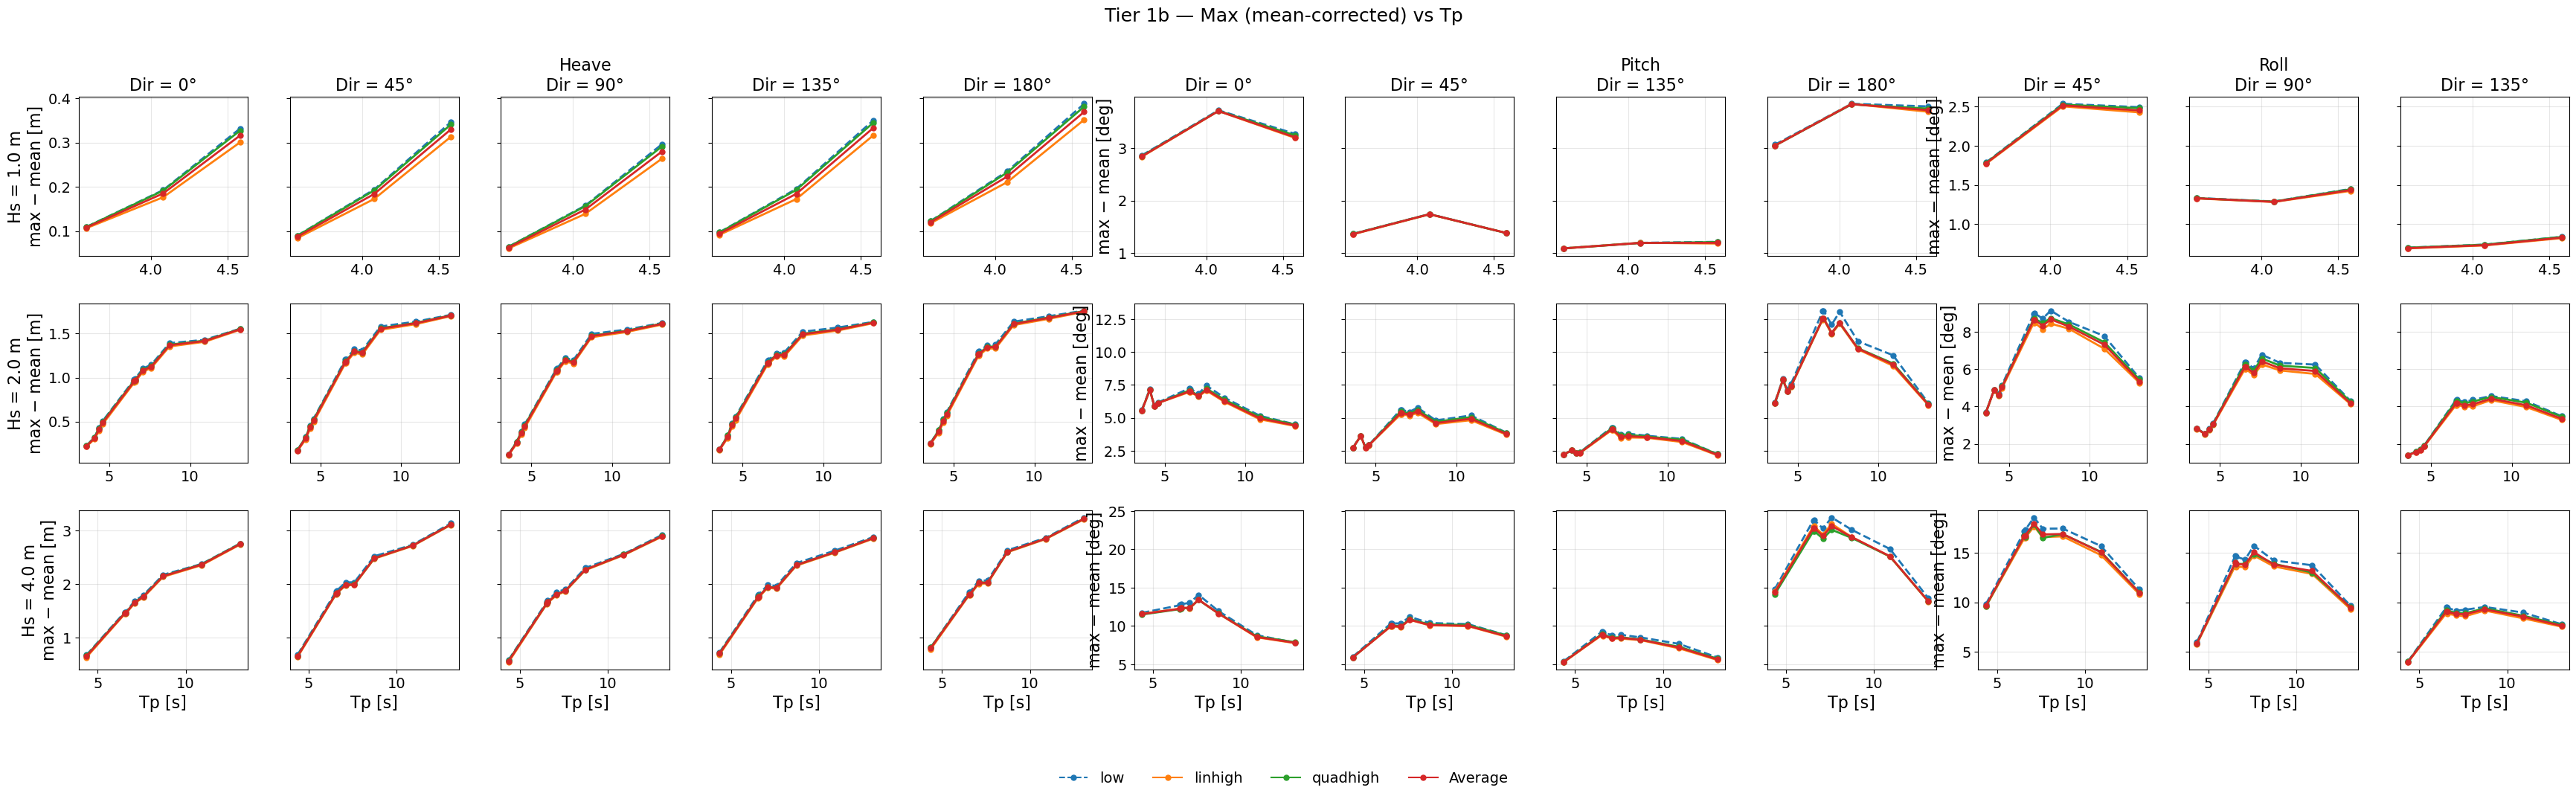

In [5]:
render_tier(
    ycol_template=lambda m: f'{m}_max',
    ylabel_template=lambda m: f'max − mean [{MOTION_UNITS[m]}]',
    show_low=True,
    super_title='Tier 1b — Max (mean-corrected) vs Tp',
)

## Tier 2 — Reduction vs `low`

Per (Hs, Tp, Direction): `(value_low − value_case) / value_low × 100%`. Positive = damping case reduces response vs reference. The `low` line is identically zero and is hidden.

Read these for: which damping case is **fractionally** most effective, and where (which Tp / which direction) does the gain matter.

In [6]:
def reduction_transform_big(d_in, motion, ycol):
    return compute_reduction(d_in, ycol).assign(**{ycol: lambda x: x['reduction_pct']})

def reduction_transform_per(d_in, motion, ycol):
    return compute_reduction(d_in, ycol).assign(**{ycol: lambda x: x['reduction_pct']})

### Tier 2a — Reduction in std

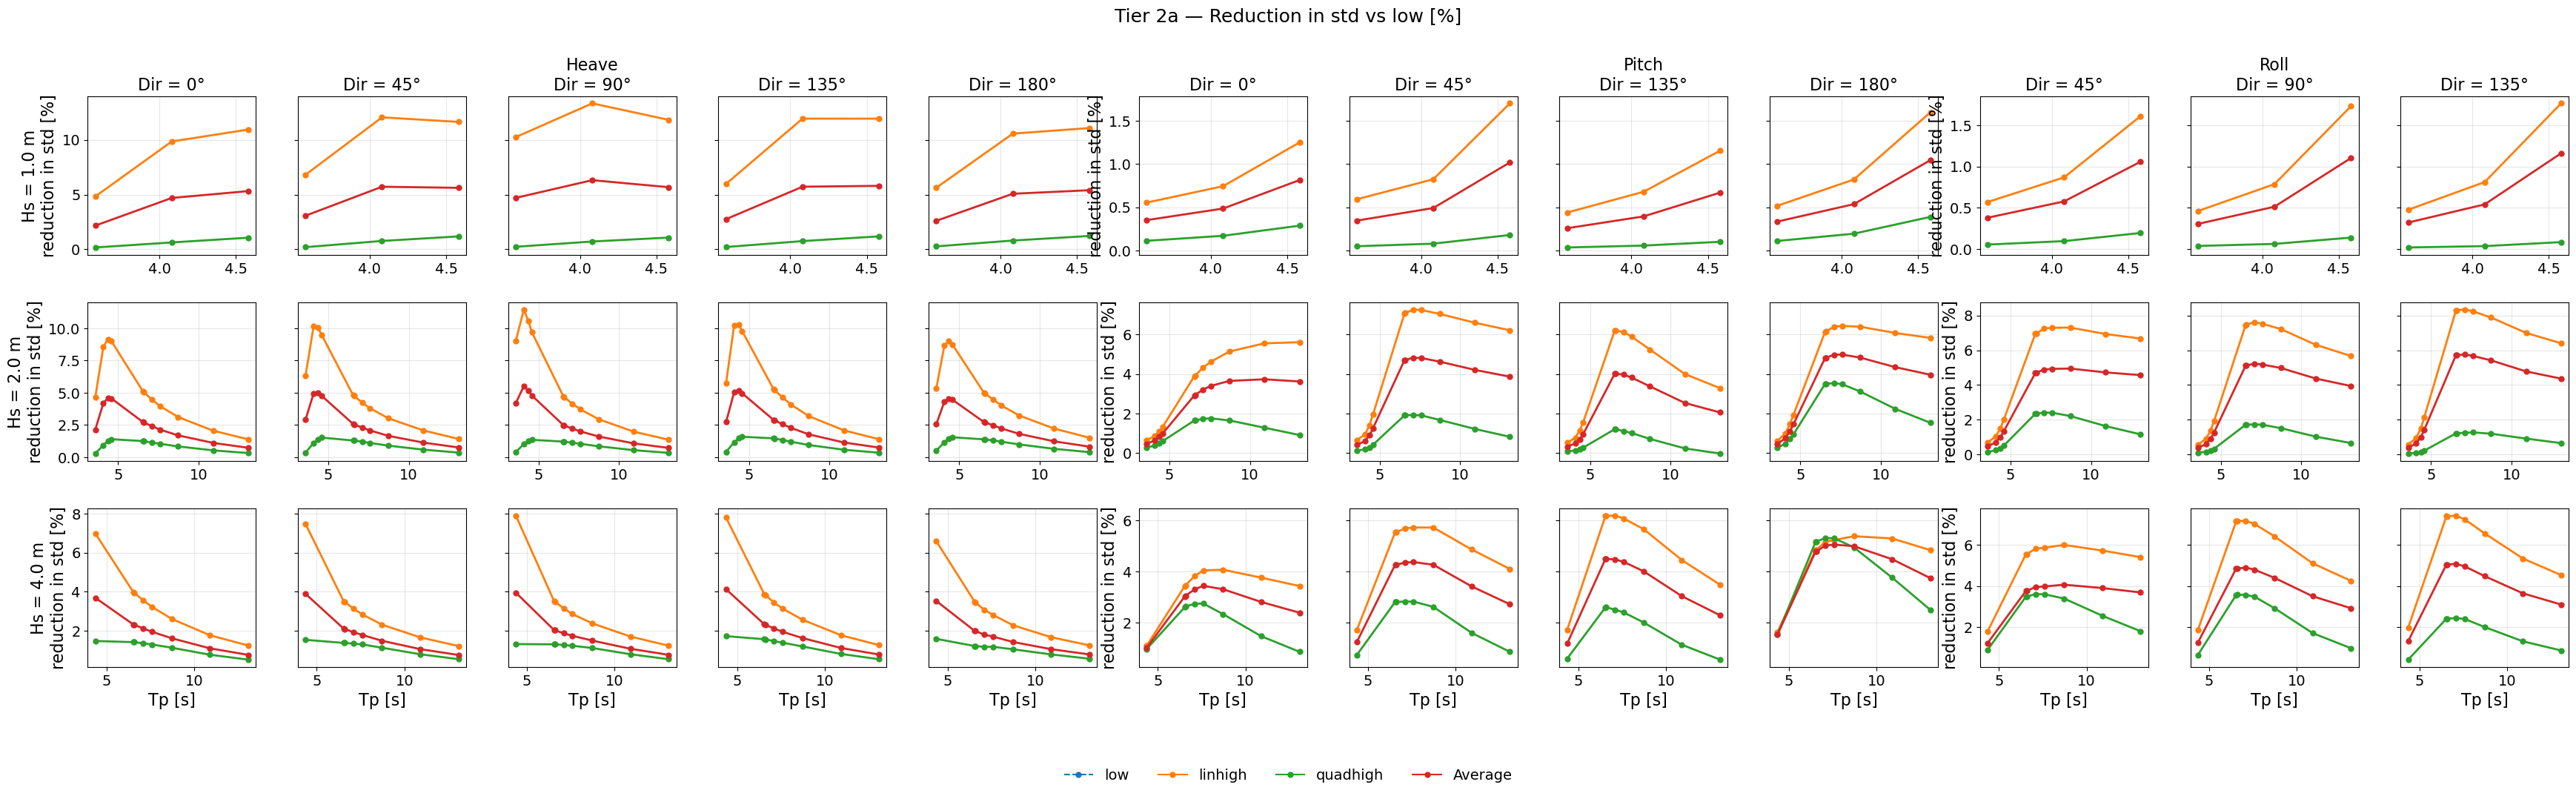

In [7]:
render_tier(
    ycol_template=lambda m: f'{m}_std',
    ylabel_template=lambda m: 'reduction in std [%]',
    show_low=False,
    transform_big=reduction_transform_big,
    transform_per=reduction_transform_per,
    super_title='Tier 2a — Reduction in std vs low [%]',
)

### Tier 2b — Reduction in max

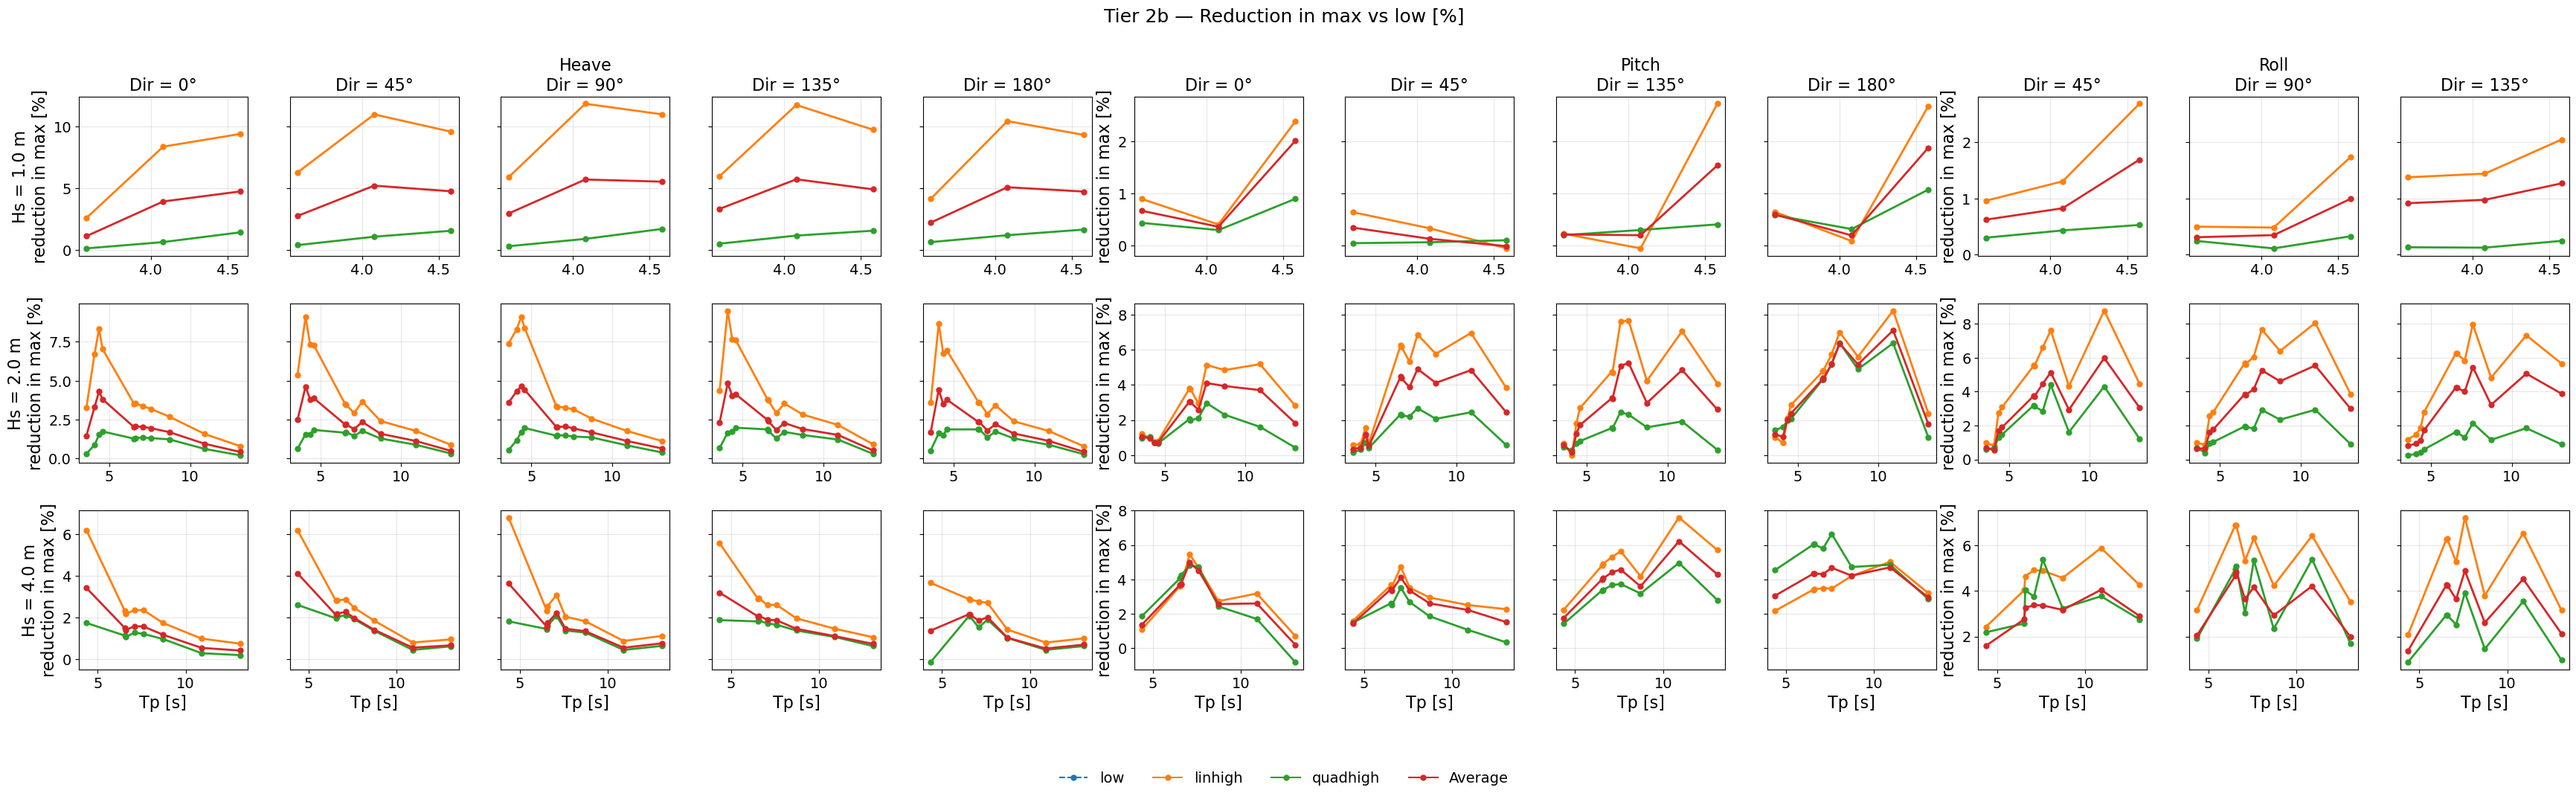

In [8]:
render_tier(
    ycol_template=lambda m: f'{m}_max',
    ylabel_template=lambda m: 'reduction in max [%]',
    show_low=False,
    transform_big=reduction_transform_big,
    transform_per=reduction_transform_per,
    super_title='Tier 2b — Reduction in max vs low [%]',
)

## Tier 3 — Peak factor (max / std)

Peak factor indicates the "peakiness" of the response. For a narrow-banded Gaussian process over a ~3h sea state, expect 3.5–4.0. Higher values suggest non-linear or extreme behavior. Comparing peak factors across damping cases shows whether damping primarily flattens the std or whether it disproportionately suppresses extremes.

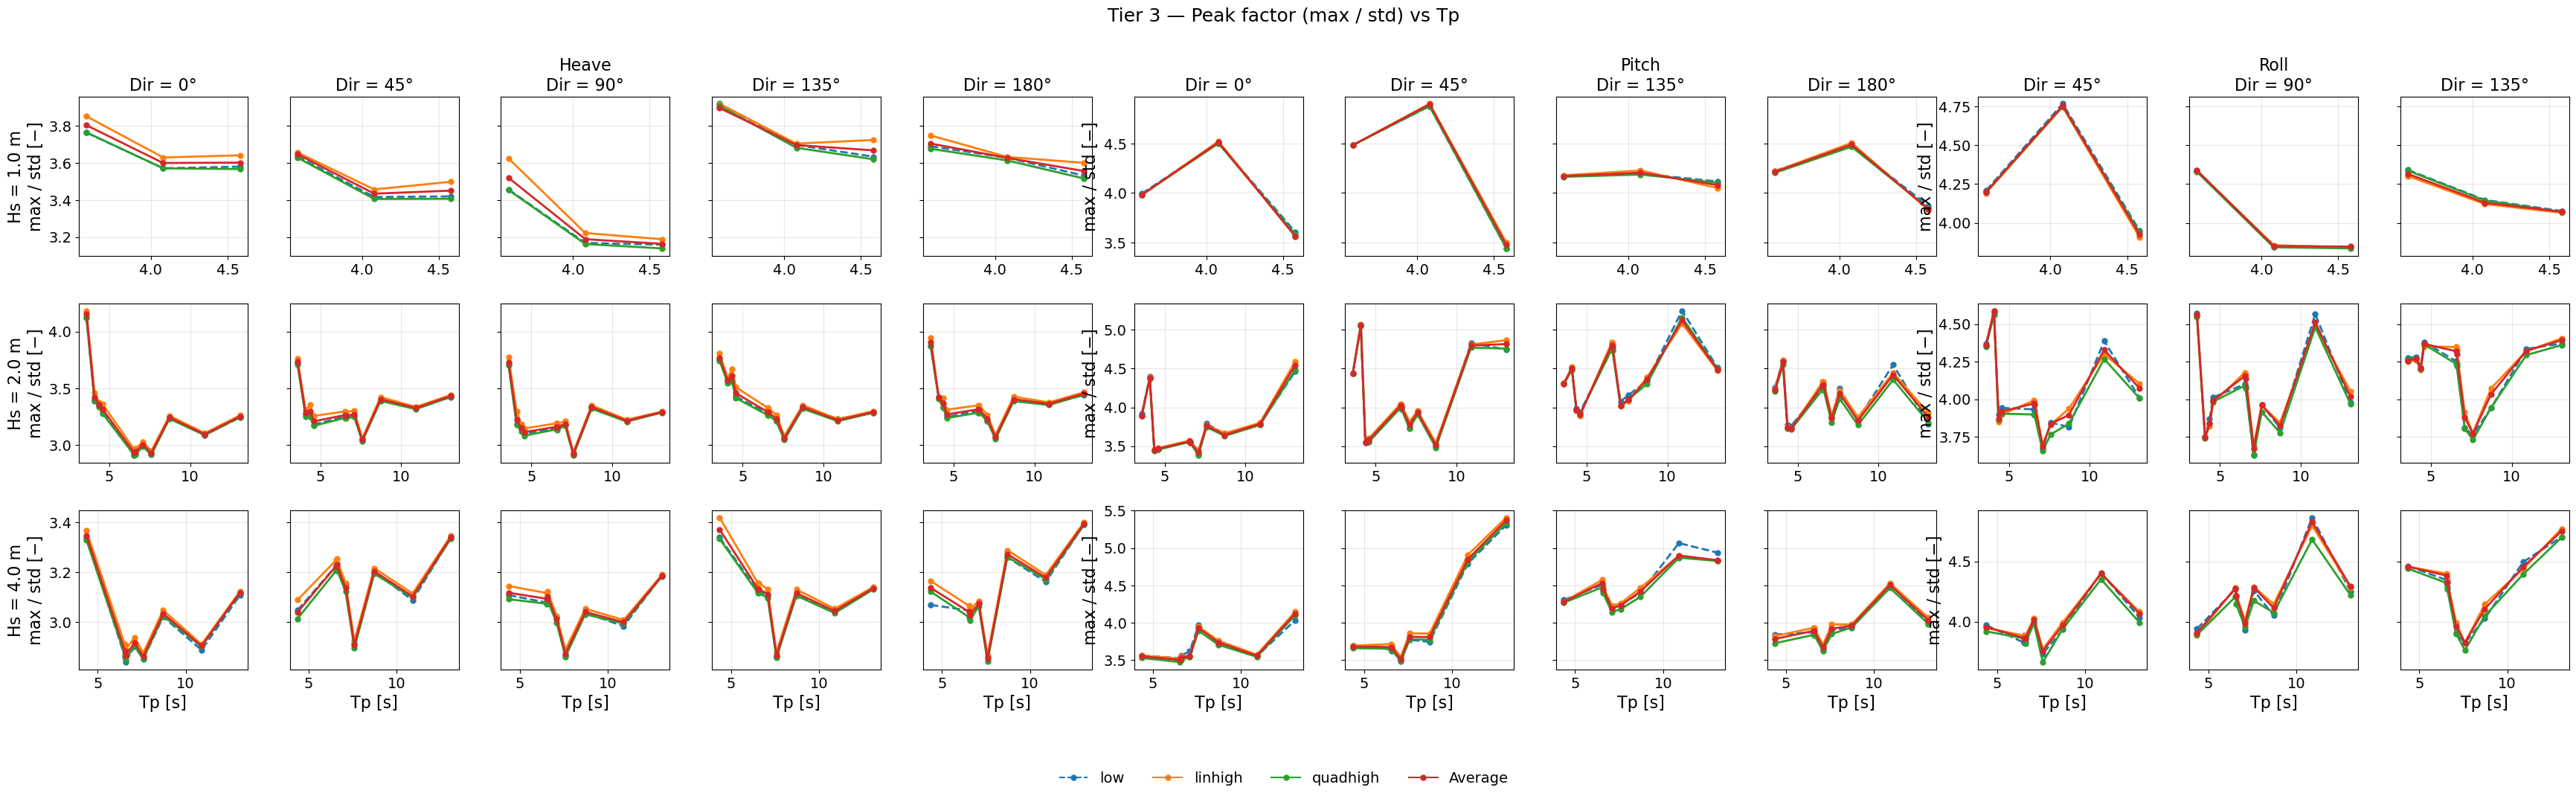

In [9]:
def peakfactor_transform_big(d_in, motion, ycol):
    out = d_in.copy()
    out[ycol] = out[f'{motion}_max'] / out[f'{motion}_std']
    return out

def peakfactor_transform_per(d_in, motion, ycol):
    out = d_in.copy()
    out[ycol] = out[f'{motion}_max'] / out[f'{motion}_std']
    return out

render_tier(
    ycol_template=lambda m: f'{m}_peakfactor',
    ylabel_template=lambda m: 'max / std [−]',
    show_low=True,
    transform_big=peakfactor_transform_big,
    transform_per=peakfactor_transform_per,
    super_title='Tier 3 — Peak factor (max / std) vs Tp',
)

## Tier 4 — Heatmaps of reduction over (Tp, Direction)

For each motion: one figure with a grid of (Hs rows) × (non-reference damping cases as columns). Color = `(std_low − std_case) / std_low × 100%`. Direction on the y-axis, Tp on the x-axis. This is the overview of where each damper helps most.

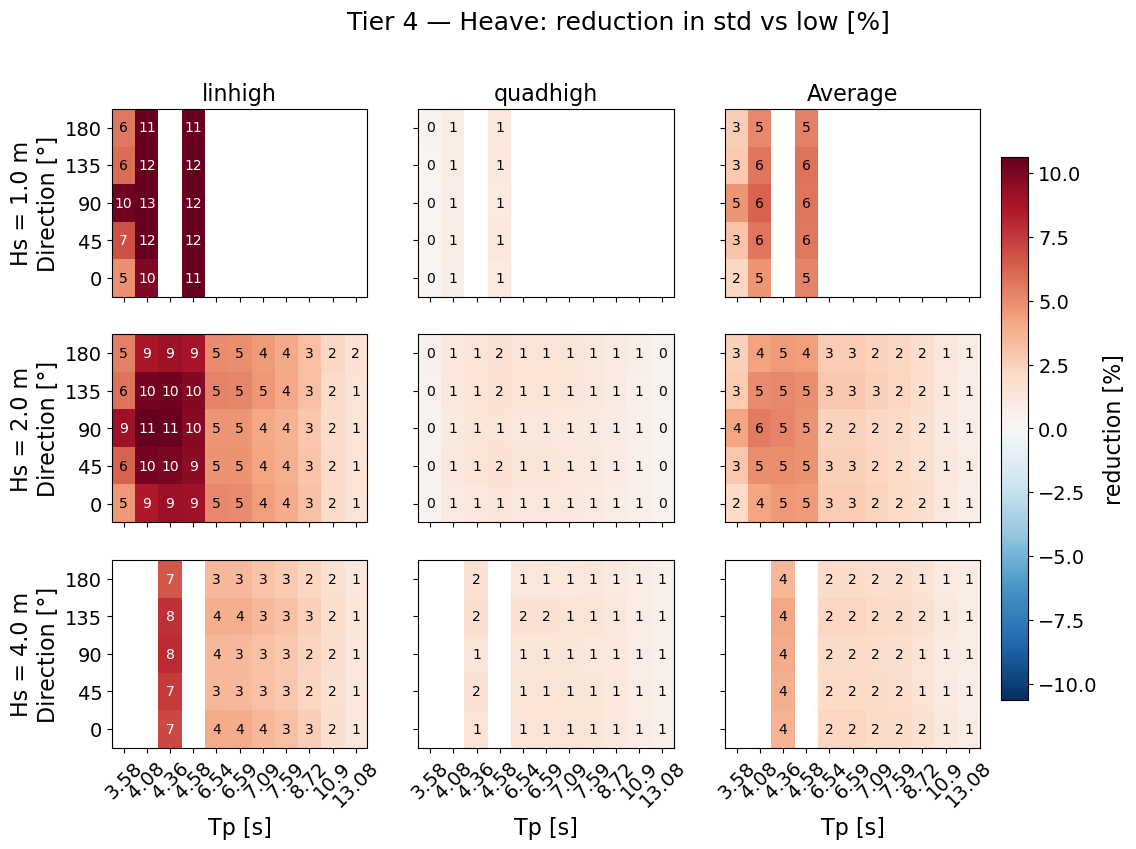

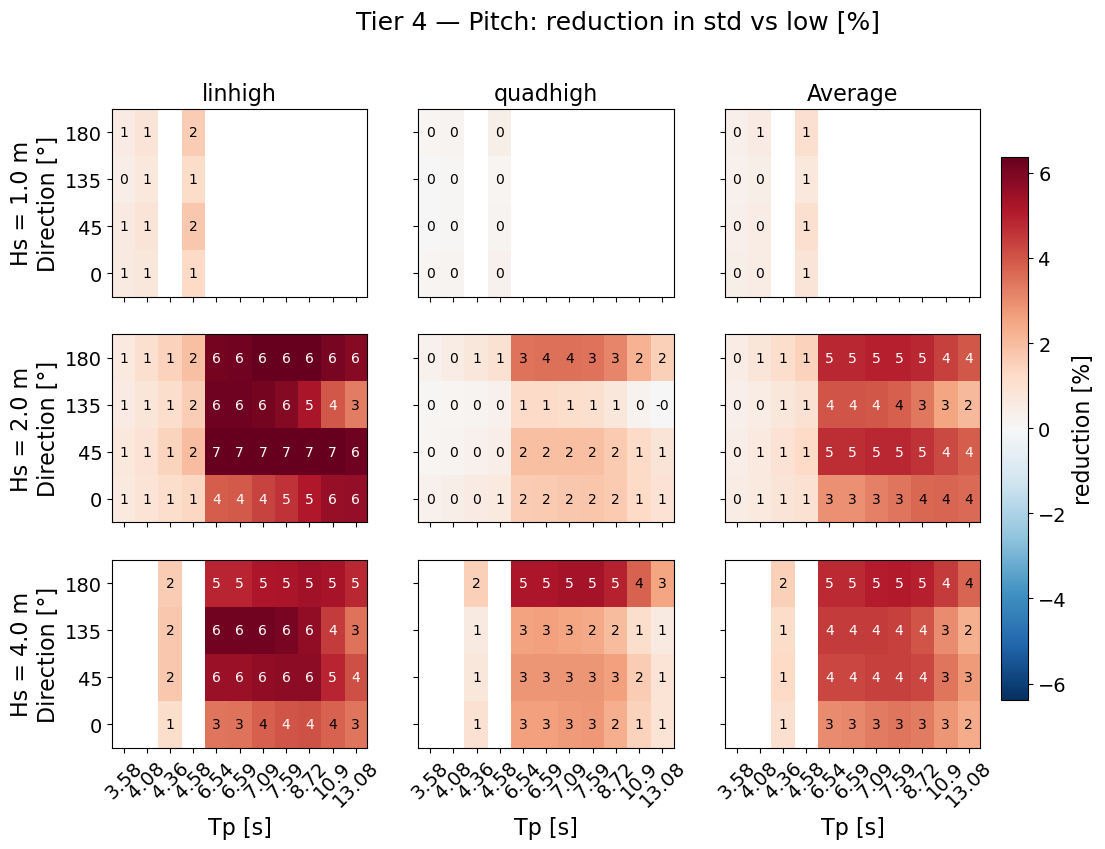

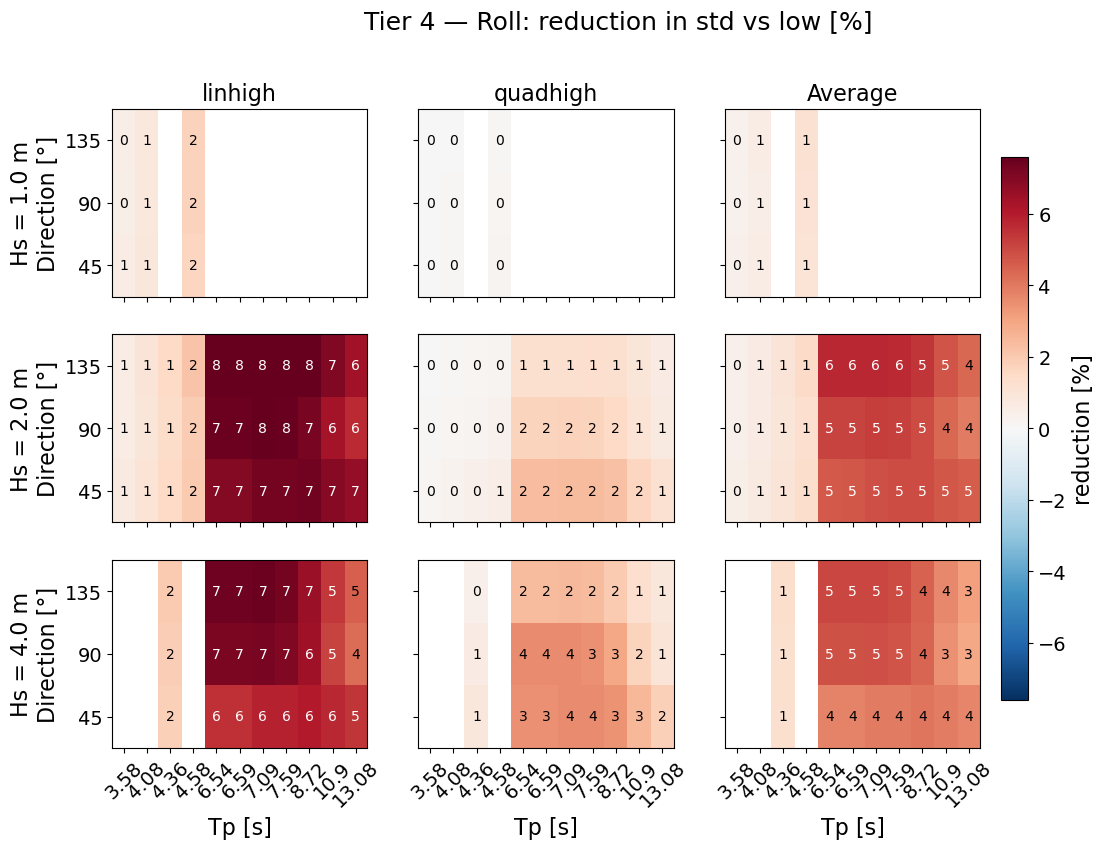

In [10]:
from matplotlib.colors import TwoSlopeNorm

def heatmap_for_motion(motion, value_col):
    d_sub = filter_motion(df, motion)
    d_red = compute_reduction(d_sub, value_col)

    hss = hs_values()
    cases = [c for c in DAMP_ORDER if c != REFERENCE_CASE]
    dirs = directions_for(motion)
    tps = sorted(d_sub['Tp'].unique())

    # symmetric color range from data
    vmax = np.nanpercentile(np.abs(d_red['reduction_pct'].values), 98)
    vmax = max(vmax, 5.0)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    fig, axes = plt.subplots(
        len(hss), len(cases),
        figsize=(4.5 * len(cases), 2.6 * len(hss) + 0.5),
        squeeze=False, sharex=True, sharey=True,
    )

    for i, hs in enumerate(hss):
        for j, case in enumerate(cases):
            ax = axes[i, j]
            cell = d_red[(d_red['Hs'] == hs) & (d_red['damp_config'] == case)]
            # pivot: rows = directions, cols = Tp
            pivot = cell.pivot_table(
                index='Direction', columns='Tp',
                values='reduction_pct', aggfunc='mean'
            ).reindex(index=dirs, columns=tps)

            im = ax.imshow(
                pivot.values, aspect='auto', origin='lower',
                cmap='RdBu_r', norm=norm,
                extent=[0, len(tps), 0, len(dirs)],
                interpolation='nearest',
            )
            ax.set_xticks(np.arange(len(tps)) + 0.5)
            ax.set_xticklabels([f'{t:g}' for t in tps], rotation=45, fontsize=TICK_SIZE)
            ax.set_yticks(np.arange(len(dirs)) + 0.5)
            ax.set_yticklabels(dirs, fontsize=TICK_SIZE)

            if i == 0:
                ax.set_title(DAMP_LABELS[case], fontsize=LABEL_SIZE)
            if j == 0:
                ax.set_ylabel(f'Hs = {hs} m\nDirection [°]', fontsize=LABEL_SIZE)
            if i == len(hss) - 1:
                ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

            # annotate cells
            for ii in range(pivot.shape[0]):
                for jj in range(pivot.shape[1]):
                    v = pivot.values[ii, jj]
                    if np.isnan(v):
                        continue
                    ax.text(jj + 0.5, ii + 0.5, f'{v:.0f}',
                            ha='center', va='center',
                            fontsize=TICK_SIZE - 4,
                            color='black' if abs(v) < vmax * 0.6 else 'white')

    fig.suptitle(
        f'Tier 4 — {MOTION_LABELS[motion]}: reduction in {value_col.split("_")[1]} vs low [%]',
        fontsize=TITLE_SIZE, y=1.00,
    )
    cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label('reduction [%]', fontsize=LABEL_SIZE)
    cbar.ax.tick_params(labelsize=TICK_SIZE)
    plt.show()


for m in MOTIONS:
    heatmap_for_motion(m, f'{m}_std')

### Tier 4b — Same heatmaps for max (mean-corrected)

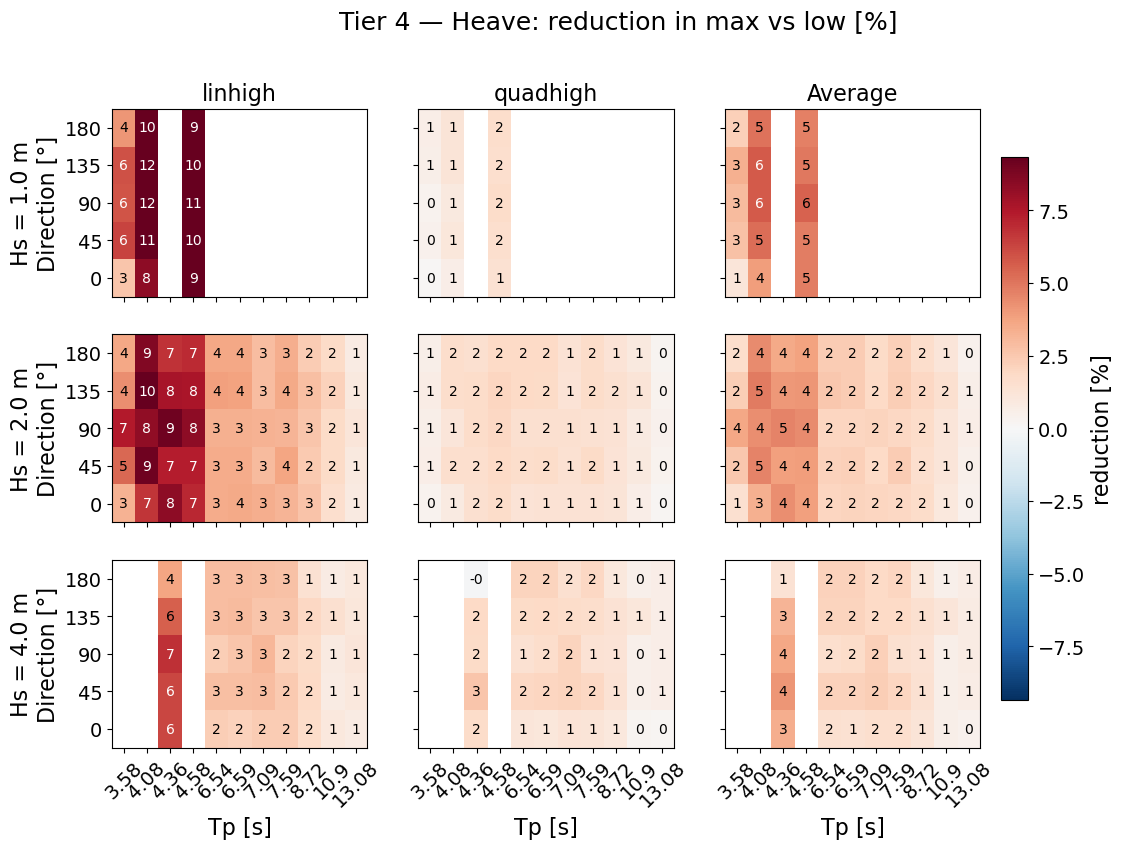

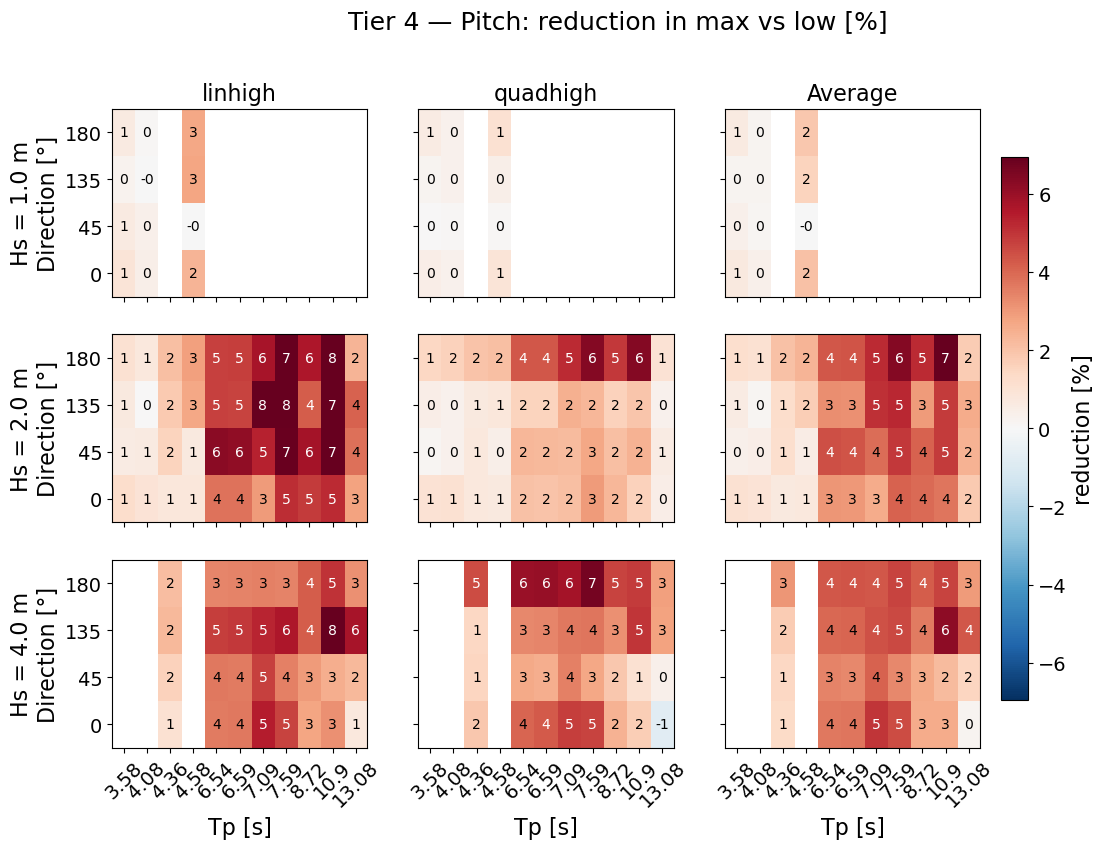

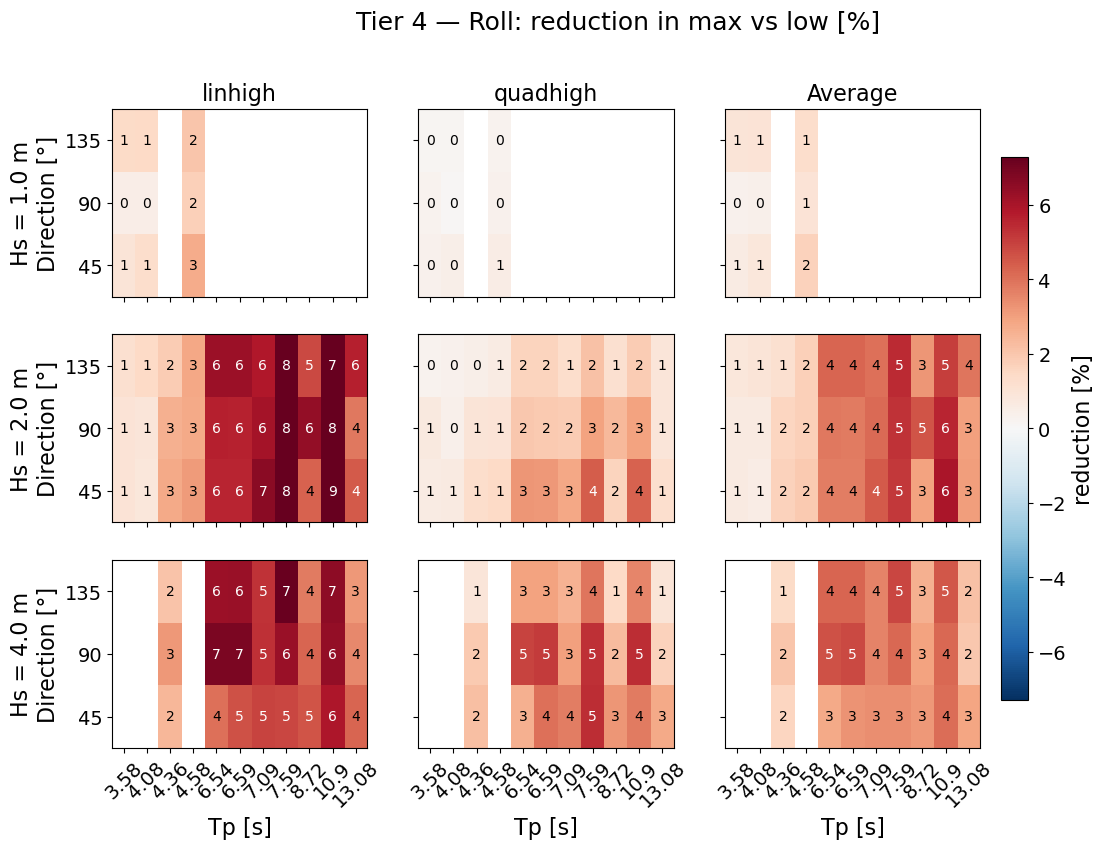

In [11]:
for m in MOTIONS:
    heatmap_for_motion(m, f'{m}_max')